# E-Commerce Product Sales – Exploratory Data Analysis
**F.Y. BCA Semester I – Division B | Group 14**

Dataset: Kaggle *E-Commerce Product Sales* (`ecommerce_dataset.csv`, 1,000 rows × 7 columns).
This notebook reproduces every table, number and chart used in the project report.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("charts", exist_ok=True)
pd.options.display.float_format = "{:,.2f}".format
plt.rcParams.update({"font.size": 13, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, GREEN, RED = "#2E75B6", "#ED7D31", "#70AD47", "#C00000"
FIGSIZE = (7.9, 4.9)

def save(fig, name):
    fig.tight_layout()
    fig.savefig(f"charts/{name}.png", dpi=200)
    plt.show()

## 1–3. Load the data, dataset description and variables

In [2]:
df = pd.read_csv("ecommerce_dataset.csv")
print("Shape (rows, columns):", df.shape)
df.head()

Shape (rows, columns): (1000, 7)


,product_id,product_name,category,price,units_sold,rating,in_stock
0,1,Camera,Electronics,391.46,8,4.50,True
1,2,Shoes,Fashion,"1,091.88",333,3.00,True
2,3,Backpack,Fashion,893.51,200,3.80,True
3,4,Watch,Fashion,162.30,87,5.00,True
4,5,Camera,Electronics,"1,378.94",43,1.50,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    1000 non-null   int64  
 1   product_name  1000 non-null   str    
 2   category      996 non-null    str    
 3   price         1000 non-null   float64
 4   units_sold    1000 non-null   int64  
 5   rating        1000 non-null   float64
 6   in_stock      1000 non-null   bool   
dtypes: bool(1), float64(2), int64(2), str(2)
memory usage: 48.0 KB


## 5. Data quality assessment

In [4]:
print("Missing values per column:")
print(df.isna().sum(), "\n")
print("Duplicate rows (ignoring product_id):", df.drop(columns="product_id").duplicated().sum())
print("Duplicate product_id values:", df["product_id"].duplicated().sum())
print("Price <= 0:", (df["price"] <= 0).sum(), "| Units sold <= 0:", (df["units_sold"] <= 0).sum())
print("Ratings outside 1-5:", (~df["rating"].between(1, 5)).sum())
print("\nRows with a missing category:")
df[df["category"].isna()]

Missing values per column:
product_id      0
product_name    0
category        4
price           0
units_sold      0
rating          0
in_stock        0
dtype: int64 

Duplicate rows (ignoring product_id): 0
Duplicate product_id values: 0
Price <= 0: 0 | Units sold <= 0: 0
Ratings outside 1-5: 0

Rows with a missing category:


,product_id,product_name,category,price,units_sold,rating,in_stock
102,103,Camera,NaN,615.52,172,1.10,True
315,316,Mouse,NaN,"1,494.54",301,1.40,True
479,480,Keyboard,NaN,"1,362.65",86,3.80,True
995,996,Mouse,NaN,681.42,277,2.50,True


In [5]:
# Every product name belongs to exactly one category in the complete rows,
# so the 4 missing categories can be filled from the product name.
known = df.dropna(subset=["category"])
assert known.groupby("product_name")["category"].nunique().max() == 1
mapping = known.drop_duplicates("product_name").set_index("product_name")["category"]
df["category"] = df["category"].fillna(df["product_name"].map(mapping))

print("Missing values after cleaning:", int(df.isna().sum().sum()))
print(df["category"].value_counts())

Missing values after cleaning: 0
category
Electronics    603
Fashion        397
Name: count, dtype: int64


In [6]:
# The dataset has no sales/revenue column, so derive it.
df["sales"] = df["price"] * df["units_sold"]
print("Total derived sales: ₹{:,.2f}".format(df["sales"].sum()))

Total derived sales: ₹189,167,121.68


## 6. Descriptive statistics

In [7]:
cols = ["price", "units_sold", "rating", "sales"]
stats = df[cols].agg(["count", "mean", "median", "std", "min", "max"]).T
stats["skewness"] = df[cols].skew()
stats

,count,mean,median,std,min,max,skewness
price,"1,000.00",759.02,777.61,423.37,10.35,"1,499.04",-0.03
units_sold,"1,000.00",250.51,254.00,142.87,1.00,499.00,-0.01
rating,"1,000.00",2.98,3.00,1.16,1.00,5.00,0.01
sales,"1,000.00","189,167.12","140,943.26","162,501.30",265.50,"719,827.56",0.95


## 9. Grouping and aggregation

In [8]:
by_category = df.groupby("category").agg(
    records=("sales", "size"), total_sales=("sales", "sum"), avg_sales=("sales", "mean"),
    units_sold=("units_sold", "sum"), avg_rating=("rating", "mean"),
    avg_price=("price", "mean"), in_stock=("in_stock", "sum"))
by_category["sales_share_%"] = by_category["total_sales"] / df["sales"].sum() * 100
by_category

,records,total_sales,avg_sales,units_sold,avg_rating,avg_price,in_stock,sales_share_%
category,,,,,,,,
Electronics,603,"113,481,736.97","188,195.25",145696,3.04,787.67,488,59.99
Fashion,397,"75,685,384.71","190,643.29",104816,2.90,715.50,315,40.01


In [9]:
by_product = df.groupby("product_name").agg(
    records=("sales", "size"), total_sales=("sales", "sum"), avg_sales=("sales", "mean"),
    avg_rating=("rating", "mean"), avg_price=("price", "mean")).sort_values("total_sales", ascending=False)
by_product

,records,total_sales,avg_sales,avg_rating,avg_price
product_name,,,,,
Laptop,118,"22,166,402.69","187,850.87",3.08,779.25
Watch,107,"22,025,880.55","205,849.35",2.83,752.37
Mouse,107,"20,308,538.85","189,799.43",3.12,756.75
Smartphone,110,"19,984,606.25","181,678.24",2.88,804.72
Backpack,100,"19,762,851.34","197,628.51",2.97,705.83
Keyboard,91,"19,165,870.73","210,613.96",3.23,819.74
T-shirt,96,"17,379,336.75","181,034.76",2.92,695.94
Camera,94,"16,934,184.23","180,150.90",3.03,750.07
Shoes,94,"16,517,316.07","175,716.13",2.89,703.81


## 7, 8 and 11. Visualisation (Figures 1–8)

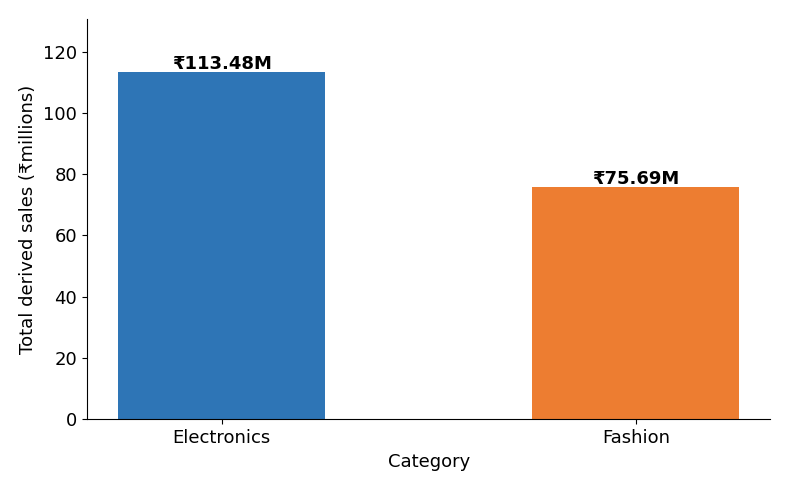

In [10]:
# Figure 1 - total derived sales by category
c = df.groupby("category")["sales"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.bar(c.index, c.values / 1e6, color=[BLUE, ORANGE], width=0.5)
for b, v in zip(bars, c.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1, f"₹{v/1e6:,.2f}M", ha="center", fontweight="bold")
ax.set(xlabel="Category", ylabel="Total derived sales (₹millions)", ylim=(0, c.max() / 1e6 * 1.15))
save(fig, "fig1_sales_by_category")

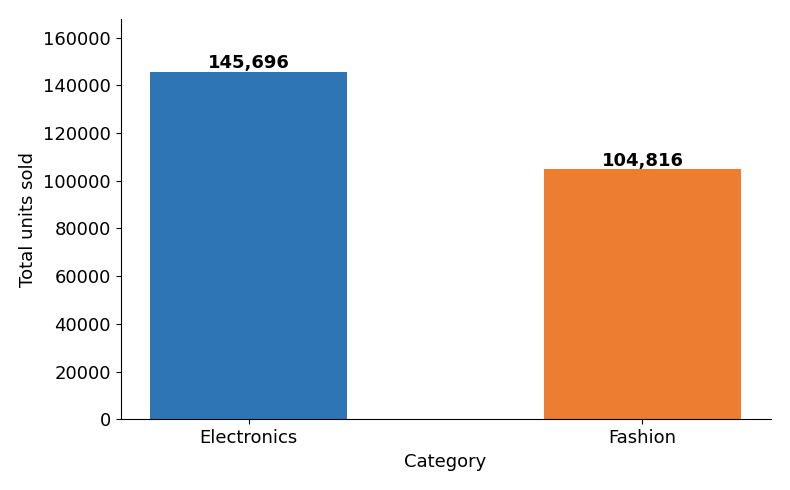

In [11]:
# Figure 2 - total units sold by category
u = df.groupby("category")["units_sold"].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.bar(u.index, u.values, color=[BLUE, ORANGE], width=0.5)
for b, v in zip(bars, u.values):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1500, f"{v:,}", ha="center", fontweight="bold")
ax.set(xlabel="Category", ylabel="Total units sold", ylim=(0, u.max() * 1.15))
save(fig, "fig2_units_by_category")

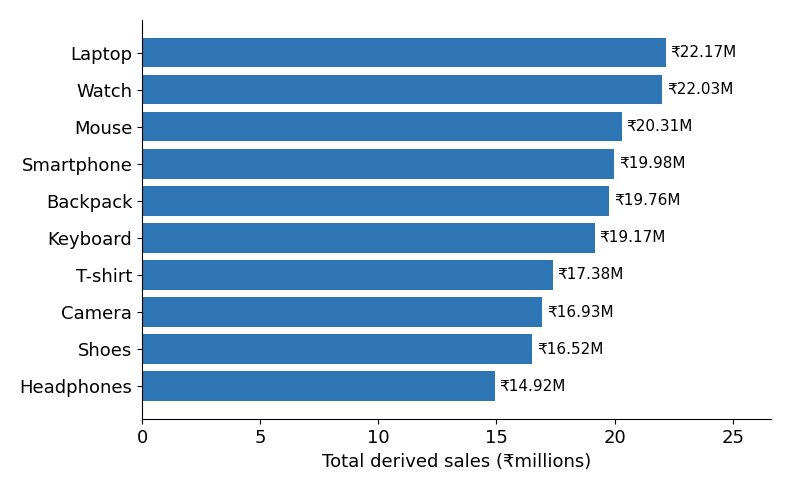

In [12]:
# Figure 3 - total derived sales by product
p = df.groupby("product_name")["sales"].sum().sort_values()
fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.barh(p.index, p.values / 1e6, color=BLUE)
for b, v in zip(bars, p.values):
    ax.text(v / 1e6 + 0.2, b.get_y() + b.get_height() / 2, f"₹{v/1e6:,.2f}M", va="center", fontsize=11)
ax.set(xlabel="Total derived sales (₹millions)", xlim=(0, p.max() / 1e6 * 1.2))
save(fig, "fig3_sales_by_product")

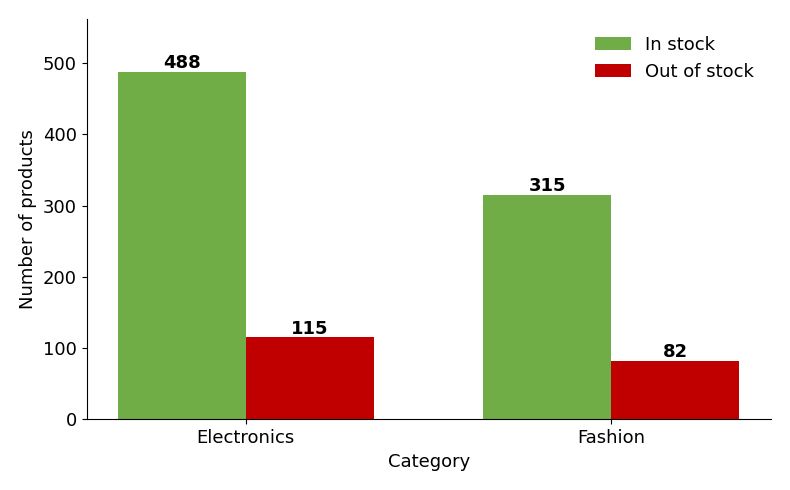

In [13]:
# Figure 4 - stock status by category
s = df.groupby(["category", "in_stock"]).size().unstack()
s = s.rename(columns={True: "In stock", False: "Out of stock"})[["In stock", "Out of stock"]]
x, w = np.arange(len(s)), 0.35
fig, ax = plt.subplots(figsize=FIGSIZE)
b1 = ax.bar(x - w / 2, s["In stock"], w, color=GREEN, label="In stock")
b2 = ax.bar(x + w / 2, s["Out of stock"], w, color=RED, label="Out of stock")
for group in (b1, b2):
    for b in group:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 5, int(b.get_height()), ha="center", fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(s.index)
ax.set(xlabel="Category", ylabel="Number of products", ylim=(0, s.values.max() * 1.15))
ax.legend(frameon=False)
save(fig, "fig4_stock_by_category")

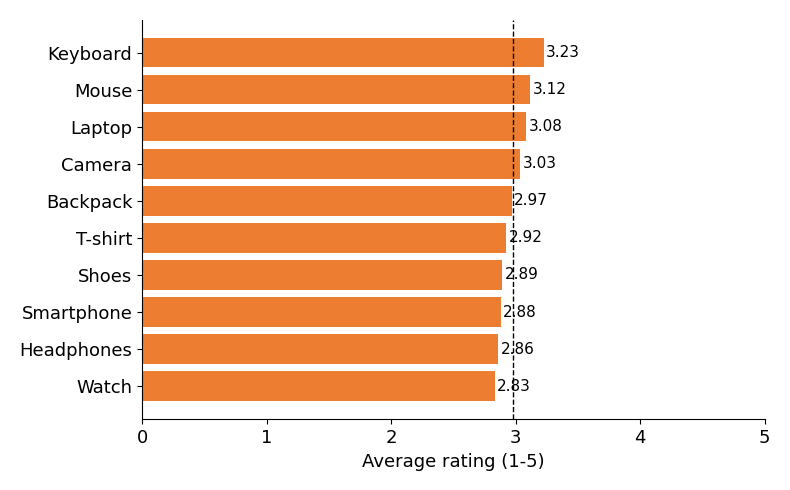

In [14]:
# Figure 5 - average rating by product
r = df.groupby("product_name")["rating"].mean().sort_values()
fig, ax = plt.subplots(figsize=FIGSIZE)
bars = ax.barh(r.index, r.values, color=ORANGE)
for b, v in zip(bars, r.values):
    ax.text(v + 0.02, b.get_y() + b.get_height() / 2, f"{v:.2f}", va="center", fontsize=11)
ax.axvline(df["rating"].mean(), color="black", ls="--", lw=1)
ax.set(xlabel="Average rating (1-5)", xlim=(0, 5))
save(fig, "fig5_rating_by_product")

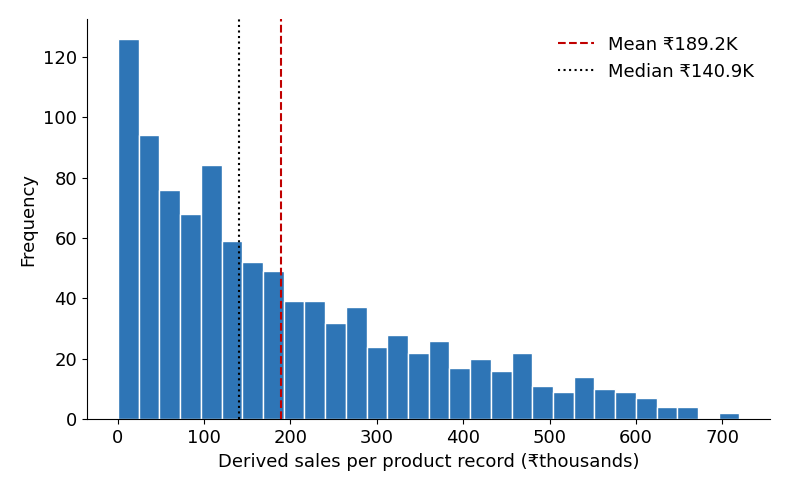

In [15]:
# Figure 6 - distribution of derived sales
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(df["sales"] / 1e3, bins=30, color=BLUE, edgecolor="white")
ax.axvline(df["sales"].mean() / 1e3, color=RED, ls="--", label=f"Mean ₹{df['sales'].mean()/1e3:,.1f}K")
ax.axvline(df["sales"].median() / 1e3, color="black", ls=":", label=f"Median ₹{df['sales'].median()/1e3:,.1f}K")
ax.set(xlabel="Derived sales per product record (₹thousands)", ylabel="Frequency")
ax.legend(frameon=False)
save(fig, "fig6_sales_distribution")

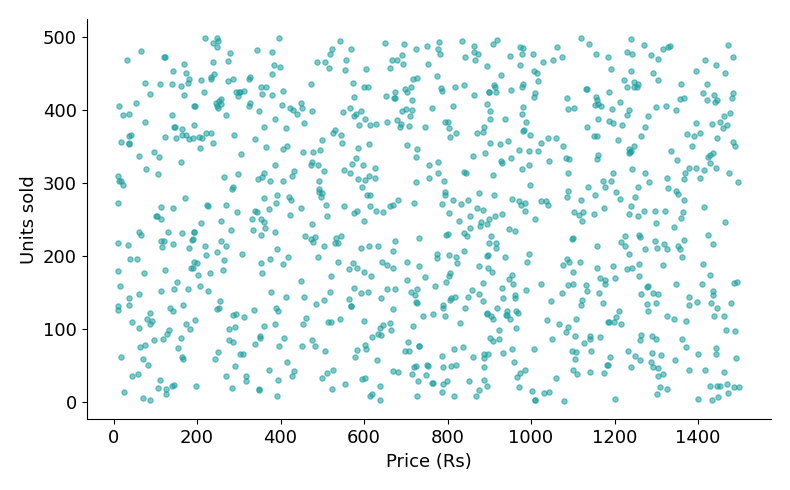

In [16]:
# Figure 7 - price vs units sold
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.scatter(df["price"], df["units_sold"], s=14, alpha=0.55, color="#1B9E9E")
ax.set(xlabel="Price (Rs)", ylabel="Units sold")
save(fig, "fig7_price_vs_units")

## 10. Correlation analysis

            Price  Units Sold  Rating
Price        1.00       -0.02   -0.02
Units Sold  -0.02        1.00   -0.01
Rating      -0.02       -0.01    1.00


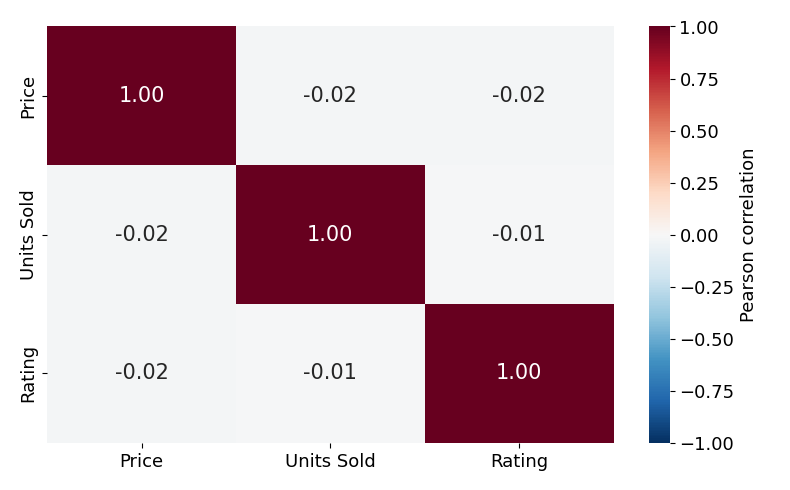

In [17]:
# product_id (identifier) and sales (derived from price x units) are excluded.
corr = df[["price", "units_sold", "rating"]].corr()
corr.columns = corr.index = ["Price", "Units Sold", "Rating"]
print(corr.round(4))

# Figure 8 - correlation heatmap
fig, ax = plt.subplots(figsize=FIGSIZE)
sns.heatmap(corr.round(2), annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            annot_kws={"size": 15}, cbar_kws={"label": "Pearson correlation"}, ax=ax)
save(fig, "fig8_correlation_heatmap")

## 12. Key findings and business insights

In [18]:
total = df["sales"].sum()
E, F = by_category.loc["Electronics"], by_category.loc["Fashion"]
print(f"Electronics: ₹{E.total_sales:,.2f} ({E.total_sales/total:.1%}) | Fashion: ₹{F.total_sales:,.2f} ({F.total_sales/total:.1%})")
print(f"Average sales per record: Electronics ₹{E.avg_sales:,.0f} vs Fashion ₹{F.avg_sales:,.0f}")
print("Top product:", by_product.index[0], f"₹{by_product.total_sales.iloc[0]:,.2f}",
      "| Lowest:", by_product.index[-1], f"₹{by_product.total_sales.iloc[-1]:,.2f}")
print("Best average rating:", by_product.avg_rating.idxmax(), round(by_product.avg_rating.max(), 2),
      "| Lowest:", by_product.avg_rating.idxmin(), round(by_product.avg_rating.min(), 2),
      "| Overall mean:", round(df.rating.mean(), 2))

out = df[~df["in_stock"]]
print(f"\nOut of stock: {len(out)} products ({len(out)/len(df):.1%}), derived sales ₹{out.sales.sum():,.2f} ({out.sales.sum()/total:.1%})")

high_price = df["price"] >= df["price"].median()
print("\nAbove vs below median price (avg units sold, avg sales per record):")
print(df.groupby(high_price).agg(units=("units_sold", "mean"), sales=("sales", "mean")).rename(index={True: "Above median", False: "Below median"}))

top10 = df.nlargest(len(df) // 10, "sales")["sales"].sum() / total
print(f"\nTop 10% of records produce {top10:.1%} of total derived sales")
print(f"Ratings >= 4: {(df.rating >= 4).mean():.1%} | Ratings < 2: {(df.rating < 2).mean():.1%}")

Electronics: ₹113,481,736.97 (60.0%) | Fashion: ₹75,685,384.71 (40.0%)
Average sales per record: Electronics ₹188,195 vs Fashion ₹190,643
Top product: Laptop ₹22,166,402.69 | Lowest: Headphones ₹14,922,134.22
Best average rating: Keyboard 3.23 | Lowest: Watch 2.83 | Overall mean: 2.98

Out of stock: 197 products (19.7%), derived sales ₹39,227,581.91 (20.7%)

Above vs below median price (avg units sold, avg sales per record):
              units      sales
price                         
Below median 253.38 100,162.63
Above median 247.65 277,816.31

Top 10% of records produce 28.2% of total derived sales
Ratings >= 4: 25.4% | Ratings < 2: 22.9%
